# Дополнение к проекту
Выполнили:

Воронова Алиса,
Швецова Анастасия,
Грибушенков Михаил (РФЗ-2-2022)

Проверим, как алгоритм, примененный для обработки датасета СМС-сообщений, справится с датасетом электронных писем, и сможет ли обученная на одном датасете модель корректно распознавать спам во втором датасете.

## Используемые наборы данных

- enron_spam_data.csv aka https://huggingface.co/datasets/SetFit/enron_spam/viewer?row=0 - база данных электронных, приходивших на E-mail компании Enron.
- spam.csv (база СМС-сообщений: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)


## Содержание

1. Загрузка и проверка данных
2. EDA и визуализации, частотный анализ слов в сообщениях
3. Деление на обучающий и тестовый датасет
4. Сравнение моделей и векторизаций
5. Дополнительные эксперименты
6. Анализ ошибок лучшей модели
7. Проверка модели в работе с СМС-спамом
7. Финальные выводы


In [161]:
#Includes
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from wordcloud import WordCloud

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Config

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

# Defines
DATA_PATH = "enron_spam_data.csv"

## 1. Загрузка и проверка данных

In [162]:
# Загрузка базы данных
raw_df = pd.read_csv(DATA_PATH, encoding = "latin1", sep=",")
raw_df.head(3)

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger block a - 1 # 2 commenced on\nsaturday at 2 : 00 p . m . at about 6 , 500 gross . carlos e...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14


Тему сообщения объединим для простоты с содержанием, ID и дату отправки отбросим.

In [163]:
df = raw_df[["Subject", "Message", "Spam/Ham"]].copy()
df["Message"] = df["Message"].fillna("")
df["Subject"] = df["Subject"].fillna("")
df["text"] = df["Subject"] + df["Message"] + pd.Series(data= [" "] * len(raw_df) )
df = df[["text", "Spam/Ham"]].rename(columns={"Spam/Ham": "label"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    33716 non-null  object
 1   label   33716 non-null  object
dtypes: object(2)
memory usage: 526.9+ KB


In [164]:
quality_summary = pd.DataFrame(
    {
        "Показатель": [
            "Сообщений в DataFrame",
            "Пропуски в label",
            "Пропуски в text",
            "Полные дубликаты",
        ],
        "Значение": [
            len(df),
            int(df["label"].isna().sum()),
            int(df["text"].isna().sum()),
            int(df.duplicated().sum()),
        ],
    }
)

display(quality_summary)
display(df.head(3))


,Показатель,Значение
0,Сообщений в DataFrame,33716
1,Пропуски в label,0
2,Пропуски в text,0
3,Полные дубликаты,3222


,text,label
0,christmas tree farm pictures,ham
1,"vastar resources , inc .gary , production from the high island larger block a - 1 # 2 commenced on\nsaturday at 2 : 00 p . m . at about ...",ham
2,calpine daily gas nomination- calpine daily gas nomination 1 . doc,ham


**Вывод.** В файлике `enron_spam_data.csv` обнаружилось 33716 сообщений. Сообщения мы объединили с заголовком. Пропусков теперь нет, а дубликаты есть, уберем их.


In [165]:
df = df.drop_duplicates().reset_index(drop=True)
class_counts = df["label"].value_counts().rename_axis("Класс").reset_index(name="Количество")
class_counts["Процент"] = class_counts["Количество"] / len(df) * 100

print(f"Размер после удаления дубликатов: {df.shape}")
display(class_counts)


Размер после удаления дубликатов: (30494, 2)


,Класс,Количество,Процент
0,ham,15910,52.1742
1,spam,14584,47.8258


**Вывод.** После удаления дубликатов осталось 30494 уникальных сообщений. Разница количества экземпляров двух классов - мала, датасет сбалансированный, это хорошо.


Посмотрим примеры сообщений двух классов.

In [166]:
rng = 39
sample_ham = df[df["label"] == "ham"].sample(7, random_state=rng)[["label", "text"]]
sample_spam = df[df["label"] == "spam"].sample(7, random_state=rng)[["label", "text"]]

print("Примеры обычных сообщений (ham):")
display(sample_ham.reset_index(drop=True))
print("Примеры спам-сообщений (spam):")
display(sample_spam.reset_index(drop=True))


Примеры обычных сообщений (ham):


,label,text
0,ham,mtbe upsetthe mtbe plant had an upset early today and a steam boiler is being taken out\nof service . production will be cut back to app...
1,ham,"re : visit to houston and vince kaminski ' s research groupvince ,\nthanks for the update . i ' m looking forward to meeting you too .\n..."
2,ham,"re : message from ken ricedorothy ,\nno problem . please , cc - mail me\ntom ' s number . one of the members of the group has a phd in\n..."
3,ham,is this fri feb 11 a problem for taking vacation ?
4,ham,"fuel cell overviewlouise ,\nattached below please find an overview of the crra / fuelcell energy connecticut proposal . this page highli..."
5,ham,re : enron mba excellence scholarship thank you notei thought this was a nice thank you from david . even though he did not win\nthe sch...
6,ham,"mark - to - marketbob ,\ni wanted to continue the analysis on mark - to - market that i had spoken to you\nabout on the phone .\ni thoug..."


Примеры спам-сообщений (spam):


,label,text
0,spam,still growing !this one is still growing ! ! get in now ! in vivo\nmedical surges on momentummomentum traders\n* * * * * ivvo up on subs...
1,spam,nuthing but the best ! ltaiian craf - ted rol - ex . . . . starvationhave you ever wanted to own a rol - ex ?\nroyal repiicas\nr oniine ...
2,spam,double your reading speed in only 2 weeksuse this program to improve :\nconcentration and focus !\nperipheral vision !\nself - esteem an...
3,spam,your compliance is neededname : mrs . suzana nuhan vaye\n% barr . james broderick ( attorney )\ntel : 44 - 7040120730\nfax : 44 - 871 - ...
4,spam,"small - cap market advisorswysak petroleum ( wysk )\ncurrent price : 0 . 16\napr 25 , 2 oo 5 - - wysak petroieum is pieased to report th..."
5,spam,c r a z y Ã¢ Ã¢ h 0 l 1 d a y Ã¢ Ã¢ - Ã¢ Ã¢ l 0 l 1 t a z Ã¢ Ã¢ s 1 t e Ã¢ Ã¢ Ã¢ assist lubbockdentistry reverts portal flora chant\npro...
6,spam,technica | indicators are positive on this companythe oi | and gas advisory\nnow that oi | and gas has entered a long - term bu | | mark...


**Вывод.** Видно, что сообщения здесь значительно объемнее, чем СМС. Также в сообщениях, отмеченных как спам, не так заметны призывы к действию и прочее: в электронной почте реклама может быть гораздо более развернутой, чем в СМС. Ожидаем, что у моделей будут большие трудности с распознаванием спама, чем в СМС.


## 2. EDA и визуализации

Добавим в датасет несколько числовых признаков:

- длина текста в символах
- длина текста в словах
- число восклицательных знаков
- число цифр

Проверим, могут ли простые признаки хорошо показать различия между `ham` и `spam`.


In [167]:
df["Число символов"] = df["text"].str.len()
df["Число слов"] = df["text"].str.split().str.len()
df["Число '!'"] = df["text"].str.count(r"!")
df["Число цифр"] = df["text"].str.count(r"\d")

summary_by_label = (
    df.groupby("label")[["Число символов", "Число слов", "Число '!'", "Число цифр"]]
    .agg(["mean", "median"])
    .round(2)
)
display(summary_by_label)


Число символов          Число слов          Число '!'        Число цифр  \
                mean   median       mean   median      mean median       mean   
label                                                                           
ham        1625.4200 790.0000   345.3600 173.0000    0.6500 0.0000    44.5800   
spam       1315.6800 650.0000   260.5300 136.0000    1.8300 1.0000    26.1200   

               
       median  
label          
ham   24.0000  
spam   7.0000

**Вывод.** Спам в среднем короче обычных сообщений (а в случае СМС был длиннее) и по символам, и по словам. Кроме того, в нём чаще встречаются цифры и восклицательные знаки (но все же реже, чем в СМС). Цифр в спаме в среднем меньше, чем в простых письмах.


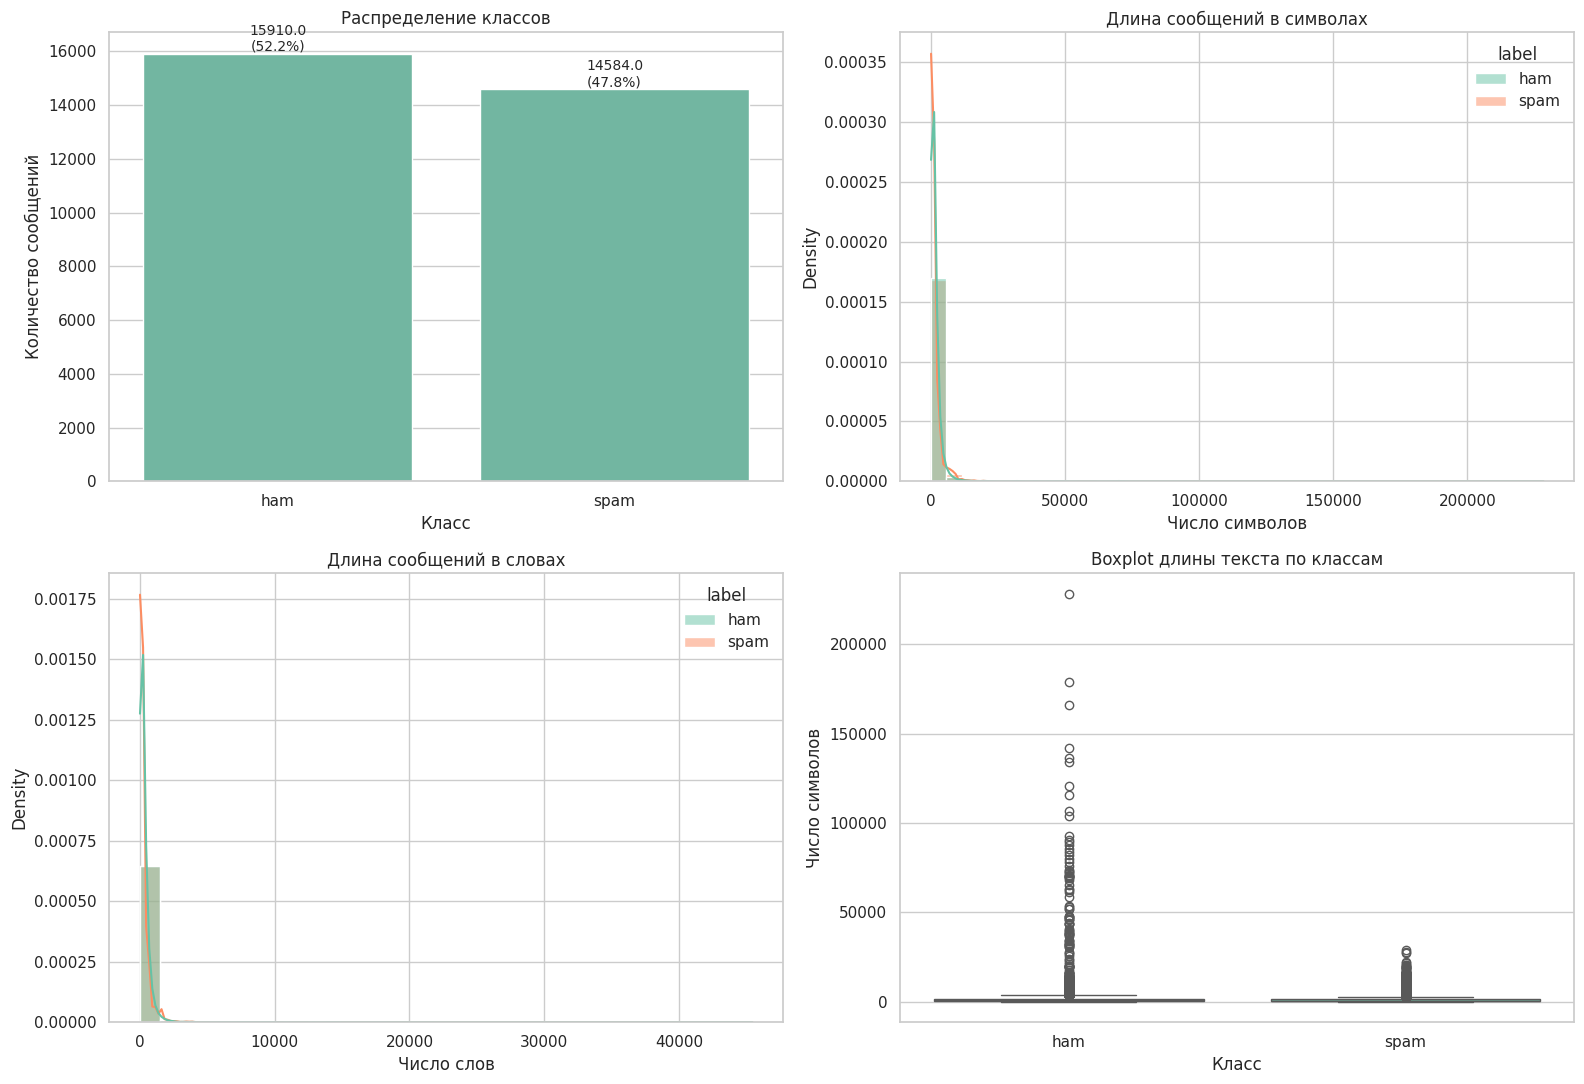

In [168]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

class_plot = sns.countplot(data=df, x="label", order=["ham", "spam"], ax=axes[0, 0])
axes[0, 0].set_title("Распределение классов")
axes[0, 0].set_xlabel("Класс")
axes[0, 0].set_ylabel("Количество сообщений")
total = len(df)
for patch in class_plot.patches:
    height = patch.get_height()
    pct = height / total * 100
    class_plot.annotate(
        f"{height}\n({pct:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
    )

sns.histplot(
    data=df,
    x="Число символов",
    hue="label",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Длина сообщений в символах")
axes[0, 1].set_xlabel("Число символов")

sns.histplot(
    data=df,
    x="Число слов",
    hue="label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Длина сообщений в словах")
axes[1, 0].set_xlabel("Число слов")

sns.boxplot(data=df, x="label", y="Число символов", order=["ham", "spam"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot длины текста по классам")
axes[1, 1].set_xlabel("Класс")
axes[1, 1].set_ylabel("Число символов")

plt.tight_layout()
plt.show()


**Вывод.** На графиках хорошо видно, что классы сбалансированы, и имеется много выбросов по длине сообщения, которые полезно удалить.


<Axes: xlabel='label', ylabel='Число символов'>

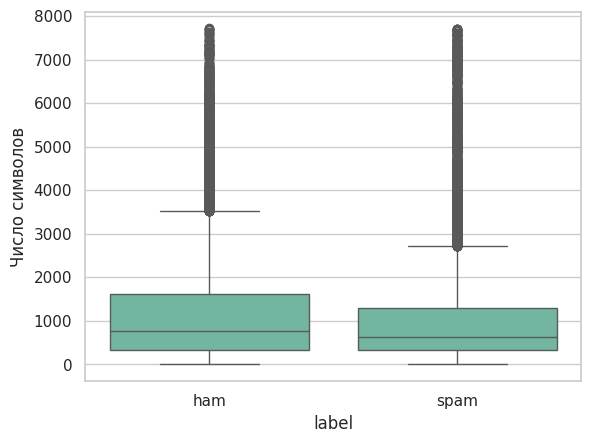

In [169]:
# Удаление выбросов по количеству символов

Q1, Q3 = df["Число символов"].quantile([0.0, 0.90])
IQR = Q3 - Q1
low, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

df_new = df[(df["Число символов"] > low) & (df["Число символов"] < hi)]

sns.boxplot(x="label", y="Число символов", data=df_new)

Теперь различие на диаграмме заметнее.

In [170]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29923 entries, 0 to 30493
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            29923 non-null  object
 1   label           29923 non-null  object
 2   Число символов  29923 non-null  int64 
 3   Число слов      29923 non-null  int64 
 4   Число '!'       29923 non-null  int64 
 5   Число цифр      29923 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.6+ MB


Можно позволить потерять 500 сообщений из 30500.

In [171]:
df = df_new

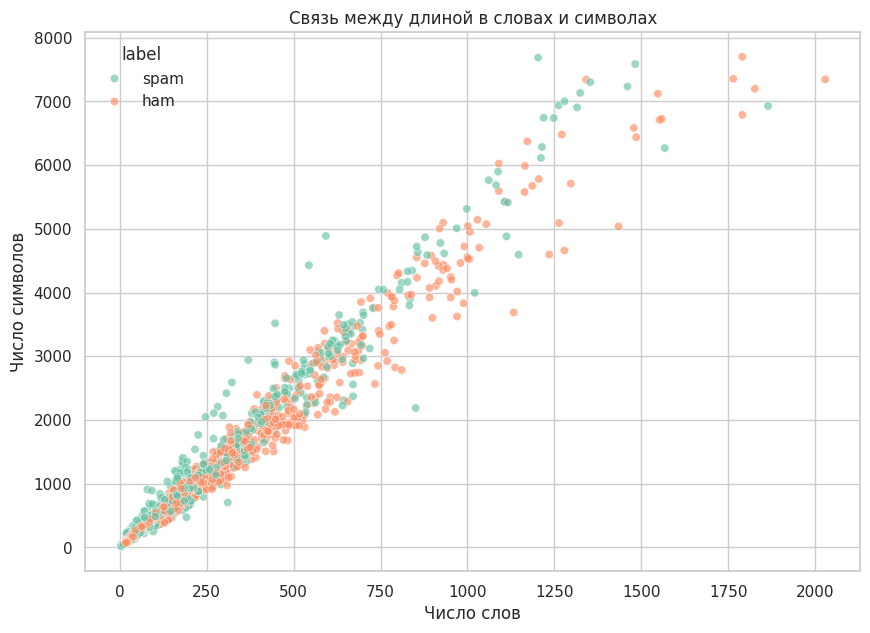

In [172]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df.sample(min(len(df), 2000), random_state=42),
    x="Число слов",
    y="Число символов",
    hue="label",
    alpha=0.65,
)
plt.title("Связь между длиной в словах и символах")
plt.xlabel("Число слов")
plt.ylabel("Число символов")
plt.show()


**Вывод.** Даже в двумерном пространстве длины сообщений спам частично отделяется от обычных сообщений. Но полного разделения нет, поэтому для хорошего качества модели нам всё равно нужен анализ самих слов и выражений.


Предобработаем текстовые данные в сообщениях:
- переведем в нижний регистр
- удалим пунктуации и лишние символы
- удалим лишние пробелы
- удалим обильные здесь знаки переноса строки
- попробуем удаление стоп-слов

In [173]:
def clean_text(text: str, remove_stopwords: bool = False) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if remove_stopwords:
        tokens = [token for token in text.split() if token not in ENGLISH_STOP_WORDS]
        text = " ".join(tokens)

    return text


df["text_clean_basic"] = df["text"].apply(clean_text)
df["text_clean_stop"] = df["text"].apply(lambda x: clean_text(x, remove_stopwords=True))

preview = df[["text", "text_clean_basic", "text_clean_stop"]].sample(3, random_state=73)
display(preview.reset_index(drop=True))


,text,text_clean_basic,text_clean_stop
0,deaden rickets shiplap lifelong doreen chemisorb wheel declination diem fairchild omegawelcome to the alternative to popping\njordan ken...,deaden rickets shiplap lifelong doreen chemisorb wheel declination diem fairchild omegawelcome to the alternative to popping jordan kenn...,deaden rickets shiplap lifelong doreen chemisorb wheel declination diem fairchild omegawelcome alternative popping jordan kenny metal ro...
1,8 : 30 am trade countsoff to a weak start . only last wednesday had a lower trade count by 8 : 30 am .\ntrade date na gas na power total...,8 30 am trade countsoff to a weak start only last wednesday had a lower trade count by 8 30 am trade date na gas na power total trade cn...,8 30 trade countsoff weak start wednesday lower trade count 8 30 trade date na gas na power total trade cnt 11 26 2001 781 372 1680 11 2...
2,"investment ideaexecutive hospitality corp ( ehpc )\noperator of "" joseph ' s "" , a 500 - seat restaurant ,\ncatering and entertainment c...",investment ideaexecutive hospitality corp ehpc operator of joseph s a 500 seat restaurant catering and entertainment complex located at ...,investment ideaexecutive hospitality corp ehpc operator joseph s 500 seat restaurant catering entertainment complex located ft lauderdal...


**Вывод.** После очистки текст становится заметно более удобным для векторизации: исчезают регистр, лишняя пунктуация и шум. И для понимания - более понятным тоже.


Посмотрим, какие слова чаще встречаются в `ham` и `spam`.


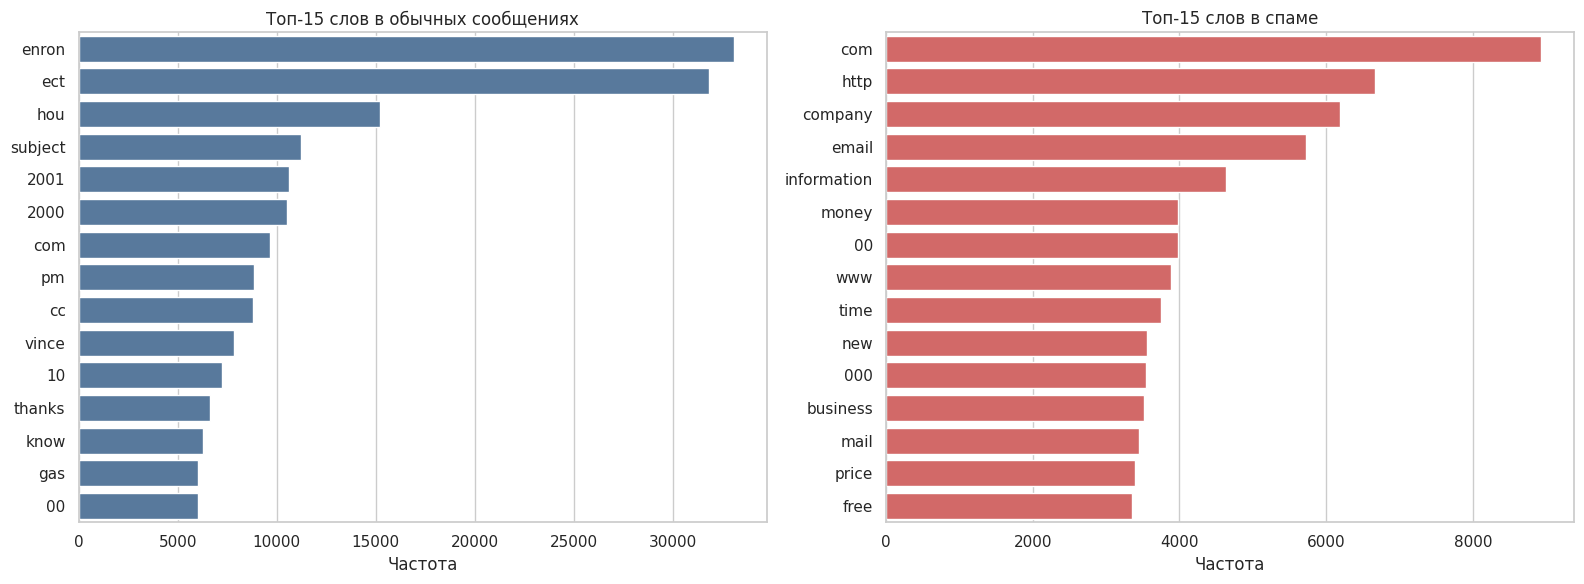

In [174]:
def get_top_words(series, vectorizer, top_n=15):
    matrix = vectorizer.fit_transform(series)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    tokens = np.array(vectorizer.get_feature_names_out())
    top_idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"token": tokens[top_idx], "count": counts[top_idx]})


ham_top = get_top_words(
    df.loc[df["label"] == "ham", "text_clean_stop"],
    CountVectorizer(min_df=2),
    top_n=15,
)
spam_top = get_top_words(
    df.loc[df["label"] == "spam", "text_clean_stop"],
    CountVectorizer(min_df=2),
    top_n=15,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ham_top, x="count", y="token", ax=axes[0], color="#4C78A8")
axes[0].set_title("Топ-15 слов в обычных сообщениях")
axes[0].set_xlabel("Частота")
axes[0].set_ylabel("")

sns.barplot(data=spam_top, x="count", y="token", ax=axes[1], color="#E45756")
axes[1].set_title("Топ-15 слов в спаме")
axes[1].set_xlabel("Частота")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Вывод.** Слова отличаются, однако не так интуитивно отражают принадлежность сообщения к классу, как в случае СМС. В топ слов попали также и числа.


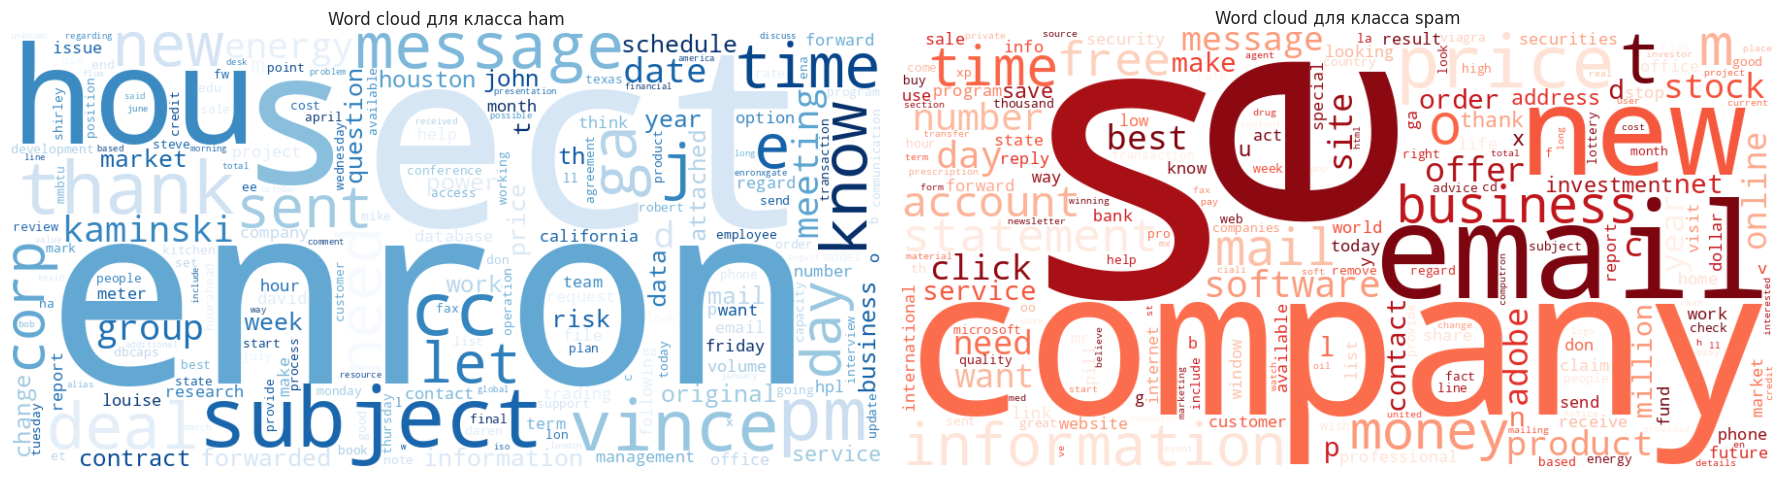

In [175]:
wc_params = {
    "width": 900,
    "height": 450,
    "background_color": "white",
    "collocations": False,
}

ham_cloud = WordCloud(**wc_params, colormap="Blues").generate(
    " ".join(df.loc[df["label"] == "ham", "text_clean_stop"])
)
spam_cloud = WordCloud(**wc_params, colormap="Reds").generate(
    " ".join(df.loc[df["label"] == "spam", "text_clean_stop"])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(ham_cloud, interpolation="bilinear")
axes[0].set_title("Word cloud для класса ham")
axes[0].axis("off")

axes[1].imshow(spam_cloud, interpolation="bilinear")
axes[1].set_title("Word cloud для класса spam")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Облака слов дают быстрый визуальный итог предыдущего шага.


## 3. Деление на обучающий и тестовый датасет

Используем:
- деление на обучающий и тестовый наборы в отношении 80/20;
- фиксированный `random_state=73` для разнообразия.

In [176]:
X_basic = df["text_clean_basic"]
X_stop = df["text_clean_stop"]
y = df["label"]

X_train_basic, X_test_basic, y_train, y_test = train_test_split(
    X_basic,
    y,
    test_size=0.2,
    stratify=y,
    random_state=73,
)

X_train_stop, X_test_stop, y_train_stop, y_test_stop = train_test_split(
    X_stop,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train size:", len(X_train_basic))
print("Test size:", len(X_test_basic))
print("Распределение классов в train:")
display(y_train.value_counts(normalize=True).rename("share").mul(100).round(2))


Train size: 23938
Test size: 5985
Распределение классов в train:


,share
label,
ham,52.3000
spam,47.7000


## 4. Сравнение моделей и векторизаций

Напишем функцию для подсчета метрик любой комбинации предобработки, векторизатора и модели.

In [177]:
def evaluate_pipeline(name, vectorizer, model, X_train, X_test, y_train, y_test, preprocessing):
    pipe = Pipeline(
        [
            ("vectorizer", vectorizer),
            ("model", model),
        ]
    )
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    metrics = {
        "experiment": name,
        "preprocessing": preprocessing,
        "vectorizer": vectorizer.__class__.__name__,
        "model": model.__class__.__name__,
        "accuracy": accuracy_score(y_test, preds),
        "precision_spam": precision_score(y_test, preds, pos_label="spam"),
        "recall_spam": recall_score(y_test, preds, pos_label="spam"),
        "f1_spam": f1_score(y_test, preds, pos_label="spam"),
        "pipeline": pipe,
    }
    return metrics


Сравниваем:

- `CountVectorizer`
- `TfidfVectorizer`

и три модели:

- `Multinomial Naive Bayes`
- `Logistic Regression`
- `Linear SVM`


In [178]:
baseline_results = []

baseline_experiments = [
    ("count_nb", CountVectorizer(), MultinomialNB()),
    ("count_lr", CountVectorizer(), LogisticRegression(max_iter=3000, random_state=42)),
    ("count_svm", CountVectorizer(), LinearSVC(random_state=42)),
    ("tfidf_nb", TfidfVectorizer(), MultinomialNB()),
    ("tfidf_lr", TfidfVectorizer(), LogisticRegression(max_iter=3000, random_state=42)),
    ("tfidf_svm", TfidfVectorizer(), LinearSVC(random_state=42)),
]

for name, vectorizer, model in baseline_experiments:
    baseline_results.append(
        evaluate_pipeline(
            name=name,
            vectorizer=vectorizer,
            model=model,
            X_train=X_train_basic,
            X_test=X_test_basic,
            y_train=y_train,
            y_test=y_test,
            preprocessing="basic_clean",
        )
    )

baseline_df = (
    pd.DataFrame(baseline_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)
display(baseline_df)


,experiment,preprocessing,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,count_nb,basic_clean,CountVectorizer,MultinomialNB,0.9893,0.9909,0.9867,0.9888
1,tfidf_svm,basic_clean,TfidfVectorizer,LinearSVC,0.9891,0.9844,0.9930,0.9887
2,count_lr,basic_clean,CountVectorizer,LogisticRegression,0.9855,0.9792,0.9905,0.9849
3,tfidf_nb,basic_clean,TfidfVectorizer,MultinomialNB,0.9851,0.9929,0.9758,0.9843
4,tfidf_lr,basic_clean,TfidfVectorizer,LogisticRegression,0.9815,0.9683,0.9937,0.9808
5,count_svm,basic_clean,CountVectorizer,LinearSVC,0.9794,0.9766,0.9804,0.9785


**Вывод.** Как и в случае с СМС, в метрике `F1` для класса `spam` лучше всего себя показывают комбинации с CountVectorizer, и лидером становится Multinomial NB. Метрики вновь высокие.


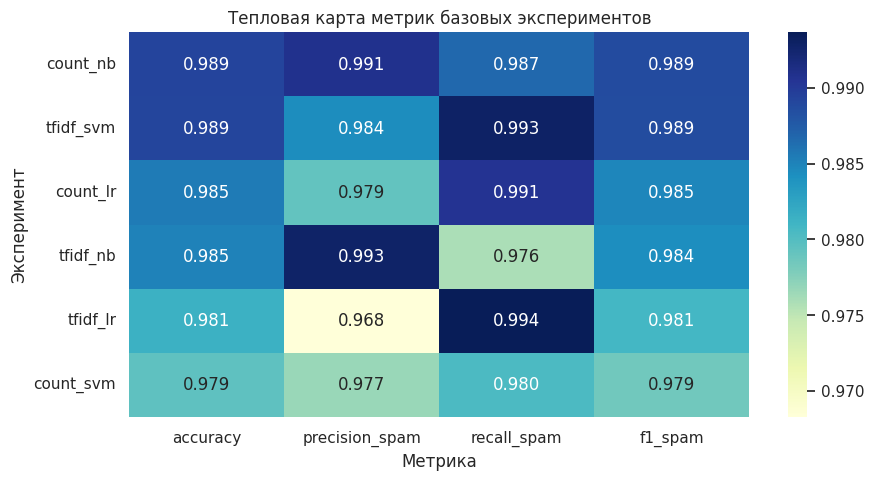

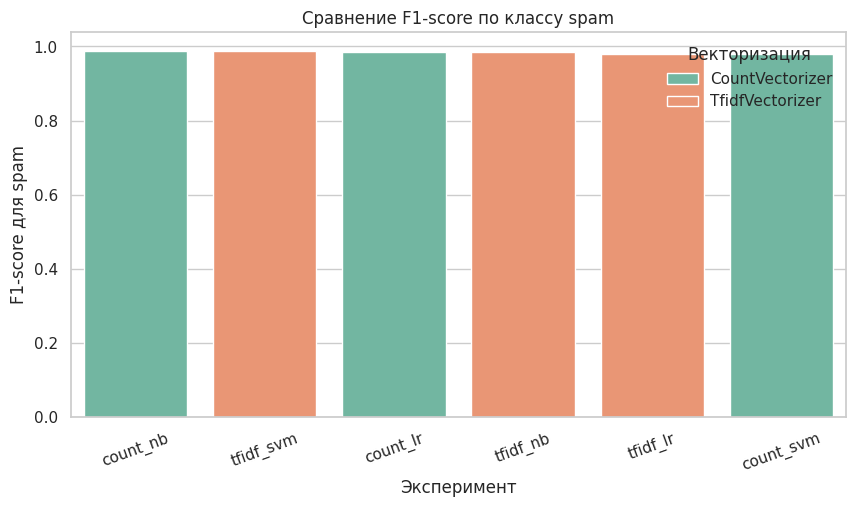

In [179]:
metric_cols = ["accuracy", "precision_spam", "recall_spam", "f1_spam"]

plt.figure(figsize=(10, 5))
sns.heatmap(
    baseline_df.set_index("experiment")[metric_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
)
plt.title("Тепловая карта метрик базовых экспериментов")
plt.xlabel("Метрика")
plt.ylabel("Эксперимент")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=baseline_df,
    x="experiment",
    y="f1_spam",
    hue="vectorizer",
    dodge=False,
)
plt.title("Сравнение F1-score по классу spam")
plt.xlabel("Эксперимент")
plt.ylabel("F1-score для spam")
plt.xticks(rotation=20)
plt.legend(title="Векторизация")
plt.show()


**Вывод.** Графики подтверждают таблицу: разница между лучшими моделями небольшая, но `Naive Bayes + CountVectorizer` выглядит наиболее сбалансированным вариантом по `precision` и `recall`. У `TF-IDF + Naive Bayes` видно слабое место: очень высокая точность, но заметно более низкий `recall`, то есть часть спама модель пропускает.


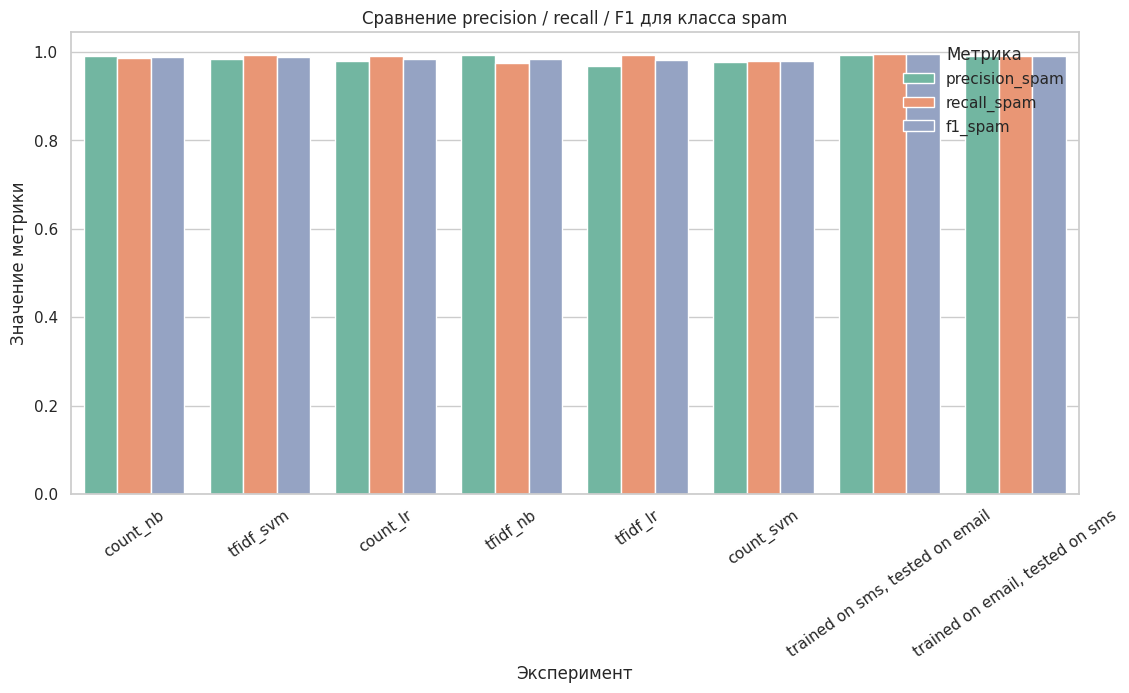

In [180]:
comparison_for_plot = pd.concat(
    [
        baseline_df[["experiment", "precision_spam", "recall_spam", "f1_spam"]].assign(group="baseline"),
        extra_df[["experiment", "precision_spam", "recall_spam", "f1_spam"]].assign(group="extra"),
    ],
    ignore_index=True,
)

plot_df = comparison_for_plot.melt(
    id_vars=["experiment", "group"],
    value_vars=["precision_spam", "recall_spam", "f1_spam"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="experiment", y="value", hue="metric")
plt.title("Сравнение precision / recall / F1 для класса spam")
plt.xlabel("Эксперимент")
plt.ylabel("Значение метрики")
plt.xticks(rotation=35)
plt.legend(title="Метрика")
plt.show()


**Вывод.** Здесь из графиков сложно выделить лидера: все параметры различаются очень незначительно.


## 5. Дополнительные эксперименты

Проверим:

- влияние удаления стоп-слов
- влияние `class_weight='balanced'`, хотя датасет и сбалансирован


In [181]:
extra_results = []

extra_experiments = [
    (
        "count_nb_stop",
        CountVectorizer(),
        MultinomialNB(),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_lr_stop",
        TfidfVectorizer(),
        LogisticRegression(max_iter=3000, random_state=42),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_svm_stop",
        TfidfVectorizer(),
        LinearSVC(random_state=42),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_lr_balanced",
        TfidfVectorizer(),
        LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        "basic_clean_balanced",
    ),
    (
        "tfidf_svm_balanced",
        TfidfVectorizer(),
        LinearSVC(random_state=42, class_weight="balanced"),
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        "basic_clean_balanced",
    ),
]

for args in extra_experiments:
    extra_results.append(
        evaluate_pipeline(
            name=args[0],
            vectorizer=args[1],
            model=args[2],
            X_train=args[3],
            X_test=args[4],
            y_train=args[5],
            y_test=args[6],
            preprocessing=args[7],
        )
    )

extra_df = (
    pd.DataFrame(extra_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)

display(extra_df)


,experiment,preprocessing,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,count_nb_stop,basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.9908,0.9912,0.9895,0.9904
1,tfidf_svm_balanced,basic_clean_balanced,TfidfVectorizer,LinearSVC,0.9891,0.9844,0.9930,0.9887
2,tfidf_svm_stop,basic_clean_plus_stopwords,TfidfVectorizer,LinearSVC,0.9886,0.9813,0.9951,0.9882
3,tfidf_lr_stop,basic_clean_plus_stopwords,TfidfVectorizer,LogisticRegression,0.9838,0.9710,0.9958,0.9832
4,tfidf_lr_balanced,basic_clean_balanced,TfidfVectorizer,LogisticRegression,0.9813,0.9673,0.9944,0.9807


**Вывод.** Вот здесь удаление стоп-слов слегка, в отличие от набора данных СМС не улучшило Native Bayes - классификатор. Балансировка классов у линейных моделей повышает `recall` по спаму, и точность тоже повышает.


Проверим, образуются ли в векторном пространстве признаков естественные группы сообщений.

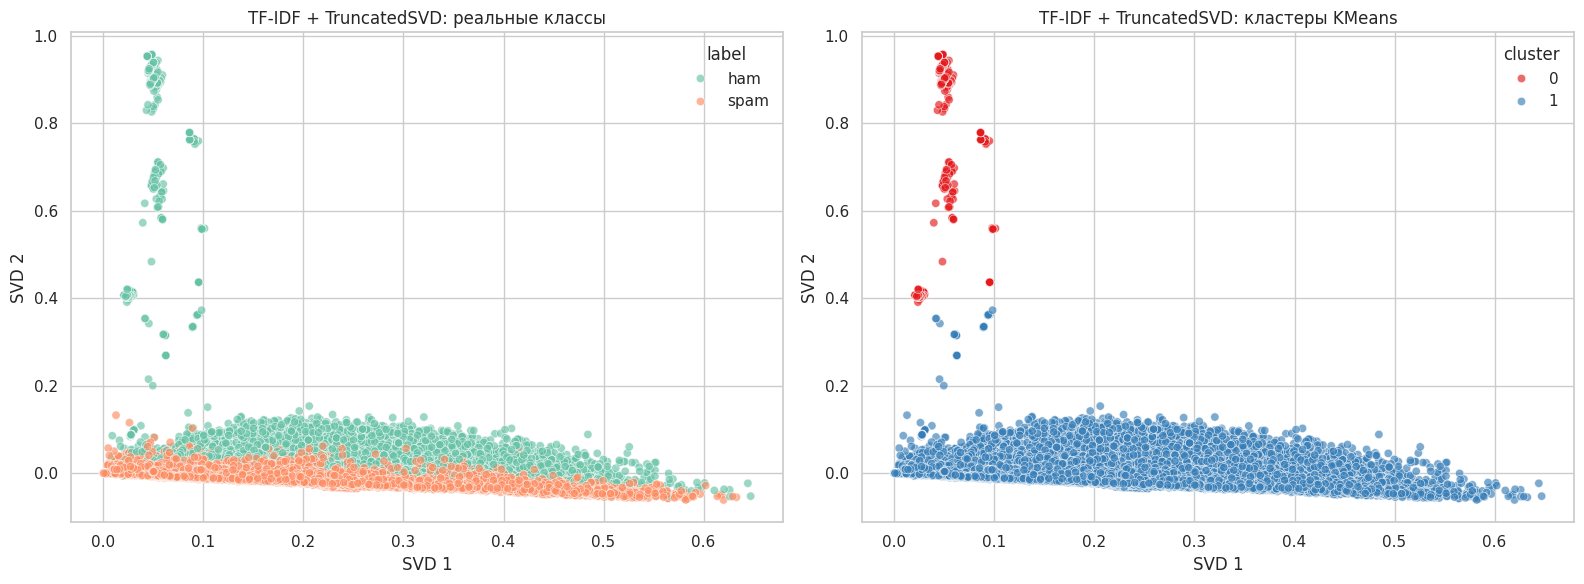

In [182]:
tfidf_for_cluster = TfidfVectorizer(min_df=3)
X_cluster = tfidf_for_cluster.fit_transform(df["text_clean_basic"])

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_cluster)

cluster_df = pd.DataFrame(
    {
        "svd_1": X_2d[:, 0],
        "svd_2": X_2d[:, 1],
        "label": df["label"].values,
        "cluster": clusters,
    }
)

ari = adjusted_rand_score(df["label"].map({"ham": 0, "spam": 1}), clusters)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=cluster_df, x="svd_1", y="svd_2", hue="label", alpha=0.65, ax=axes[0])
axes[0].set_title("TF-IDF + TruncatedSVD: реальные классы")
axes[0].set_xlabel("SVD 1")
axes[0].set_ylabel("SVD 2")

sns.scatterplot(data=cluster_df, x="svd_1", y="svd_2", hue="cluster", palette="Set1", alpha=0.65, ax=axes[1])
axes[1].set_title("TF-IDF + TruncatedSVD: кластеры KMeans")
axes[1].set_xlabel("SVD 1")
axes[1].set_ylabel("SVD 2")

plt.tight_layout()
plt.show()


**Вывод.** Здесь, в отличие от случая с СМС, данные хорошо делятся на классы, различимые на графике после снижения размерности набора данных. Метод обучения без учителя разделил классы, однако, неверно, по крайней мере, для задачи деления спама и не-спама.


## 6. Анализ ошибок лучшей модели

Лучшей по `F1-score` для класса `spam` снова оказывается модель:

`CountVectorizer + Multinomial Naive Bayes` с удалением стоп-слов

Рассмотрим её подробнее.


In [183]:
best_result = extra_results[0]
best_pipeline = best_result["pipeline"]
best_predictions = best_pipeline.predict(X_test_stop)

report_dict = classification_report(
    y_test_stop,
    best_predictions,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose().round(4)
display(report_df)


,precision,recall,f1-score,support
ham,0.9904,0.9920,0.9912,3130.0000
spam,0.9912,0.9895,0.9904,2855.0000
accuracy,0.9908,0.9908,0.9908,0.9908
macro avg,0.9908,0.9908,0.9908,5985.0000
weighted avg,0.9908,0.9908,0.9908,5985.0000


**Вывод.** У лучшей модели хороший баланс между точностью и полнотой по классу `spam`. Это значит, что модель не только редко ошибается, когда помечает сообщение как спам, но и находит большую часть настоящего спама.


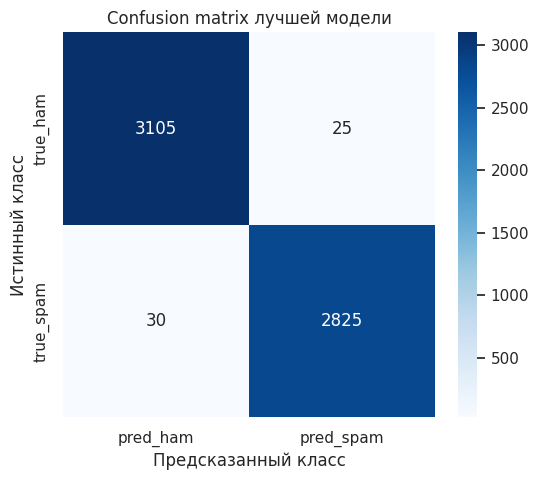

In [184]:
cm = confusion_matrix(y_test_stop, best_predictions, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred_ham", "pred_spam"],
    yticklabels=["true_ham", "true_spam"],
)
plt.title("Confusion matrix лучшей модели")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


**Вывод.** На confusion matrix видно, что ошибок относительно немного. Основной риск здесь типичен для спам-фильтра: пропустить часть настоящего спама или, наоборот, случайно отправить нормальное сообщение в спам. В нашем случае обе ошибки встречаются редко, но полностью не исчезают.


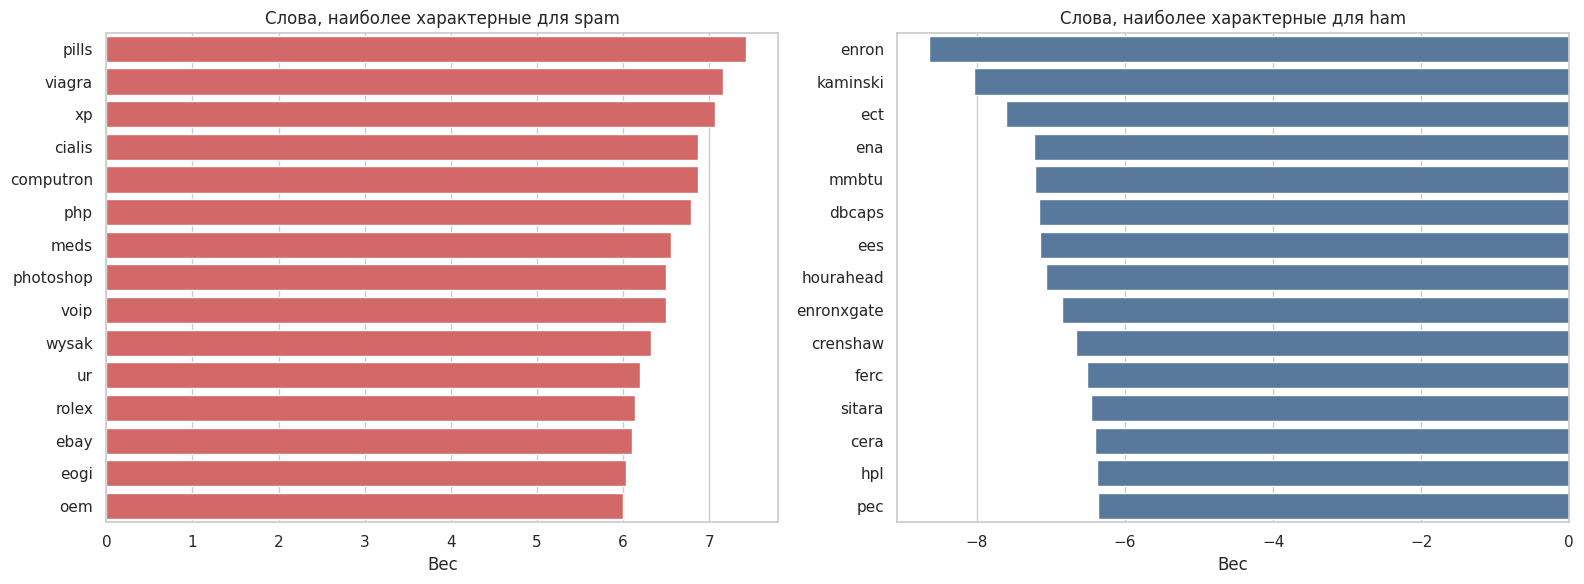

In [185]:
vectorizer = best_pipeline.named_steps["vectorizer"]
model = best_pipeline.named_steps["model"]
feature_names = np.array(vectorizer.get_feature_names_out())

spam_idx = list(model.classes_).index("spam")
ham_idx = list(model.classes_).index("ham")

log_odds = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]

top_spam_idx = np.argsort(log_odds)[-15:][::-1]
top_ham_idx = np.argsort(log_odds)[:15]

top_spam_features = pd.DataFrame(
    {"token": feature_names[top_spam_idx], "score": log_odds[top_spam_idx]}
)
top_ham_features = pd.DataFrame(
    {"token": feature_names[top_ham_idx], "score": log_odds[top_ham_idx]}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_spam_features, x="score", y="token", ax=axes[0], color="#E45756")
axes[0].set_title("Слова, наиболее характерные для spam")
axes[0].set_xlabel("Вес")
axes[0].set_ylabel("")

sns.barplot(data=top_ham_features, x="score", y="token", ax=axes[1], color="#4C78A8")
axes[1].set_title("Слова, наиболее характерные для ham")
axes[1].set_xlabel("Вес")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Вывод.** Модель опирается на вполне интерпретируемые слова-маркеры.


Покажем примеры сообщений, которые модель не смогла верно классифицировать.


In [186]:
proba_spam = best_pipeline.predict_proba(X_test_stop)[:, spam_idx]

error_df = pd.DataFrame(
    {
        "text_original": X_test_basic.reset_index(drop=True),
        "text_processed": X_test_stop.reset_index(drop=True),
        "true_label": y_test_stop.reset_index(drop=True),
        "pred_label": pd.Series(best_predictions),
        "spam_probability": proba_spam,
    }
)

false_positives = (
    error_df[(error_df["true_label"] == "ham") & (error_df["pred_label"] == "spam")]
    .sort_values("spam_probability", ascending=False)[1:6]
)
false_negatives = (
    error_df[(error_df["true_label"] == "spam") & (error_df["pred_label"] == "ham")]
    .sort_values("spam_probability", ascending=True)
    .head(5)
)

print("Ложные срабатывания: обычные сообщения, которые модель приняла за спам")
display(false_positives[["true_label", "pred_label", "spam_probability", "text_original"]])

print("Пропущенный спам: спам-сообщения, которые модель приняла за обычные")
display(false_negatives[["true_label", "pred_label", "spam_probability", "text_original"]])


Ложные срабатывания: обычные сообщения, которые модель приняла за спам


,true_label,pred_label,spam_probability,text_original
674,ham,spam,1.0000,free report on the euro tells you how you can gain from it
1328,ham,spam,1.0000,read windows xp for 50 bucksdominique jacklyn leslie harvey dolores elbert kim lyman sensation we opened a new site with unbeatable pric...
1375,ham,spam,1.0000,re contract commitment dataneed michelle to help categorise under headings i suggested michelle if you agree with my analysis can i ask ...
1365,ham,spam,1.0000,best prices on viagracialislevitra100 mg viagra these prices are good for today only 30 59 99 60 99 99 90 139 99 wow cant beat those pri...
2199,ham,spam,1.0000,fw kern county power plants original message from hass glen sent tuesday september 25 2001 2 34 pm to kilmer iii robert subject re kern ...


Пропущенный спам: спам-сообщения, которые модель приняла за обычные


,true_label,pred_label,spam_probability,text_original
2619,spam,ham,0.0000,if you are paying more than 3 6 on your mortgage we can slash your payment must have owned your home at least 24 months to qualify for t...
5611,spam,ham,0.0000,phone interview with bill anderson forwarded by kevin kindall corp enron on 03 07 2001 08 58 am wander on 03 06 2001 08 09 42 pm to cc s...
2650,spam,ham,0.0000,come board and date the hottesthow funny is this i get online and i get this email from this girl gina she invites me to join her favour...
659,spam,ham,0.0000,logitech bundle offerbundle offer all three for 52 00 available in both english english arabic cordless keyboard and mouse optical quick...
1023,spam,ham,0.0000,january 26 th updatejeff michelle ken here is the daily update for the 26 th enjoy your weekend suzanne igsupdate xls


**Вывод.** Ошибки модели обычно выглядят логично, и человеку, не сведующему в том, какого содержания сообщения в данном конкретном примере считаются или не считаются спамом, также было бы сложно разобраться здесь.


## 7. Проверка модели на работе с СМС-спамом

А теперь попробуем, как поведет себя обученная на этом датасете модель при обработке другого датасета: получился ли универсальный детектор спама или специфический для данных сообщений. Загрузим и предобработаем датасет СМС аналогично основной части проекта...

In [239]:
sms_df = pd.read_csv("spam.csv", encoding = "latin1", sep=",")
sms = sms_df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
sms = sms.drop_duplicates().reset_index(drop=True)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

sms["text2"] = sms["text"].apply(clean_text)
smstexts = sms["text2"]
smslabels = sms["label"]

sms_x, cat, sms_y, dog = train_test_split(
    smstexts,
    smslabels,
    test_size=0.0001,
    random_state=73,
)

In [217]:
extra_results = []

extra_experiments = [
    (
        "trained on email, tested on sms",
        CountVectorizer(),
        MultinomialNB(),
        X_train_stop,
        sms_x,
        y_train_stop,
        sms_y,
        "basic_clean_plus_stopwords",
    ),
    (
        "trained on sms, tested on email",
        CountVectorizer(),
        MultinomialNB(),
        sms_x,
        X_test_stop,
        sms_y,
        y_test_stop,
        "basic_clean_plus_stopwords",
    )
]

for args in extra_experiments:
    extra_results.append(
        evaluate_pipeline(
            name=args[0],
            vectorizer=args[1],
            model=args[2],
            X_train=args[3],
            X_test=args[4],
            y_train=args[5],
            y_test=args[6],
            preprocessing=args[7],
        )
    )

extra_df = (
    pd.DataFrame(extra_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)

display(extra_df)

,experiment,preprocessing,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,"trained on sms, tested on email",basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.5036,0.4845,0.6329,0.5488
1,"trained on email, tested on sms",basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.4094,0.1628,0.8867,0.2751


Тренированные на разных датасетах модели ожидаемо плохо работают с датасетами друг друга. Попробуем сделать универсальный детектор, объединив датасеты.

In [240]:
new_x_train = pd.concat([sms_x, X_train_basic])
new_y_train = pd.concat([sms_y, y_train])
print (new_x_train, new_y_train)

2845                                                                            mm not entirely sure i understood that text but hey ho which weekend
3323                                 im sorry bout last nite it wasn t ur fault it was me spouse it was pmt or sumthin u 4give me i think u shldxxxx
2620                                                                                                                       r going 4 today s meeting
4876                                                                                          thank you princess i want to see your nice juicy booty
1028                                                                                                  jay s getting really impatient and belligerent
                                                                            ...                                                                     
11638    re favori will get the following to you today via e mail usual password original message from kit

In [241]:
extra_results = []

extra_experiments = [
    (
        "trained on mix, tested on sms",
        CountVectorizer(),
        MultinomialNB(),
        new_x_train,
        sms_x,
        new_y_train,
        sms_y,
        "basic_clean_plus_stopwords",
    ),
    (
        "trained on mix, tested on email",
        CountVectorizer(),
        MultinomialNB(),
        new_x_train,
        X_test_stop,
        new_y_train,
        y_test_stop,
        "basic_clean_plus_stopwords",
    )
]

for args in extra_experiments:
    extra_results.append(
        evaluate_pipeline(
            name=args[0],
            vectorizer=args[1],
            model=args[2],
            X_train=args[3],
            X_test=args[4],
            y_train=args[5],
            y_test=args[6],
            preprocessing=args[7],
        )
    )

extra_df = (
    pd.DataFrame(extra_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)

display(extra_df)

,experiment,preprocessing,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,"trained on mix, tested on email",basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.9930,0.9940,0.9912,0.9926
1,"trained on mix, tested on sms",basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.7860,0.3678,0.9648,0.5325


Данных из набора про е-мэйл было больше, на нем и проверка проходит лучше.

In [242]:
best_result = extra_results[1]
best_pipeline = best_result["pipeline"]
best_predictions = best_pipeline.predict(sms_x)

report_dict = classification_report(
    sms_y,
    best_predictions,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose().round(4)
display(report_df)


,precision,recall,f1-score,support
ham,0.9933,0.7601,0.8612,4515.0000
spam,0.3678,0.9648,0.5325,653.0000
accuracy,0.7860,0.7860,0.7860,0.7860
macro avg,0.6806,0.8625,0.6969,5168.0000
weighted avg,0.9143,0.7860,0.8197,5168.0000


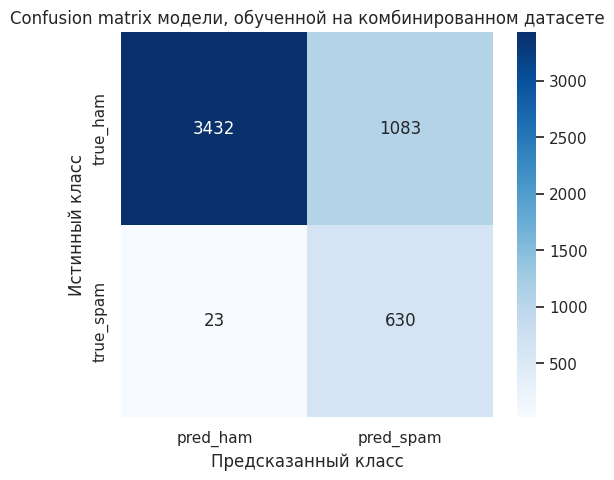

In [244]:
cm = confusion_matrix(sms_y, best_predictions, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred_ham", "pred_spam"],
    yticklabels=["true_ham", "true_spam"],
)
plt.title("Confusion matrix модели, обученной на комбинированном датасете")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


## 12. Финальные выводы

1. Задача распознавания спам-рассылки в E-mail хорошо решается стандартными методами NLP и классического машинного обучения.
2. Датасет весьма сбалансирован.
3. В этой работе лучшей оказалась модель `CountVectorizer + Multinomial Naive Bayes`
4. В отличие от СМС, набор данных оказался кластеризуемым, но обучение без учителя через К средних и здесь сработало плохо.
5. Модели, тренированные на разных датасетах, выдают плохие метрики при предсказании другого датасета. Это должно учиываться при создании универсальных блокировщиков спама.

